# 8. Gradient Descent & Optimizers
---
Backprop gives us **gradients**. Optimizers use those gradients to **update the weights**. The choice of optimizer can make a huge difference in training speed and final accuracy.

<img src="./Images/gradient_descent.jpg" width="800" height="800" />

## 8.1 Gradient Descent Variants

### Batch Gradient Descent
Use **all** training samples to compute one gradient update.
Batch Gradient Descent is a variant of the gradient descent algorithm where the entire dataset is used to compute the gradient of the loss function with respect to the parameters. In each iteration the algorithm calculates the average gradient of the loss function for all the training examples and updates the model parameters accordingly.

✅ Stable, accurate gradient  
❌ Very slow on large datasets

### Stochastic Gradient Descent (SGD)
Use **one** sample per update.

SGD is a variant of the gradient descent algorithm where the model parameters are updated using the gradient of the loss function with respect to a single training example at each iteration. Unlike batch gradient descent which uses the entire dataset SGD updates the parameters more frequently, leading to faster convergence.


✅ Fast updates, can escape local minima  
❌ Very noisy, erratic loss curve

### Mini-Batch Gradient Descent
Use a **small batch** (typically 32–256 samples) per update.
Mini-Batch Gradient Descent is a compromise between Batch Gradient Descent and Stochastic Gradient Descent. Instead of using the entire dataset or a single training example Mini-Batch Gradient Descent updates the model parameters using a small, random subset of the training data called a mini-batch.

✅ Best of both worlds — fast AND reasonably accurate  
✅ Used in practice for virtually all deep learning


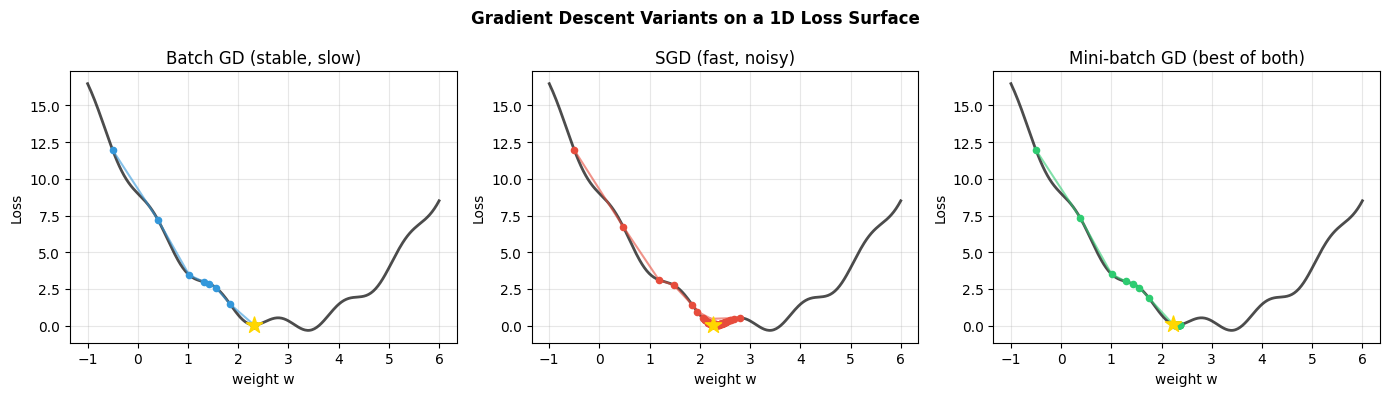

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simple 1D loss surface to visualize gradient descent
def loss_fn(w): return (w - 3)**2 + 0.5 * np.sin(5*w)
def grad_fn(w): return 2*(w - 3) + 2.5 * np.cos(5*w)

def run_gd(start, lr, n_steps=50, noise=0):
    w, path = start, [start]
    for _ in range(n_steps):
        g = grad_fn(w) + noise * np.random.randn()
        w = w - lr * g
        path.append(w)
    return path

w_range = np.linspace(-1, 6, 300)
loss_surface = loss_fn(w_range)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    ("Batch GD (stable, slow)",       0.1, 0,   '#3498DB'),
    ("SGD (fast, noisy)",             0.1, 1.5, '#E74C3C'),
    ("Mini-batch GD (best of both)",  0.1, 0.3, '#2ECC71'),
]

for ax, (title, lr, noise, col) in zip(axes, configs):
    path = run_gd(start=-0.5, lr=lr, n_steps=60, noise=noise)
    ax.plot(w_range, loss_surface, 'k-', lw=2, alpha=0.7)
    ax.scatter(path, loss_fn(np.array(path)), c=col, s=20, zorder=5)
    ax.plot(path, loss_fn(np.array(path)), '-', color=col, alpha=0.6, lw=1.5)
    ax.scatter(path[-1], loss_fn(path[-1]), c='gold', s=150, zorder=6, marker='*')
    ax.set_title(title); ax.set_xlabel("weight w"); ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)

plt.suptitle("Gradient Descent Variants on a 1D Loss Surface", fontweight='bold')
plt.tight_layout()
plt.show()


## 8.2 Adam Optimizer

**Adam (Adaptive Moment Estimation)** is the go-to optimizer for most deep learning tasks.

It keeps track of:
- $m_t$: running mean of gradients (like momentum)
- $v_t$: running mean of **squared** gradients (adapts learning rate per weight)

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$w_t = w_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Typical values: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\alpha = 0.001$

✅ Adaptive per-parameter learning rates  
✅ Works well with little tuning  
✅ **Default choice for most deep learning projects**


## 8.4 Learning Rate: The Most Important Hyperparameter

| Learning Rate | Effect |
|---|---|
| Too high | Loss oscillates or diverges (explodes) |
| Too low | Training is very slow, may get stuck |
| Just right | Smooth, fast decrease in loss |

A common strategy: start with `lr = 0.001` (Adam) or `lr = 0.01` (SGD), then adjust based on the loss curve.


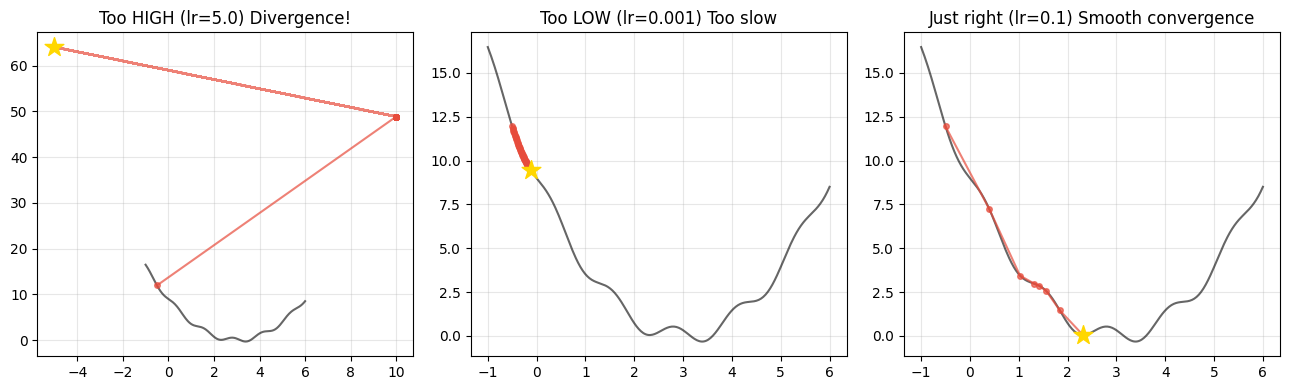

In [4]:
# Visualizing the effect of learning rate
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (lr, title) in zip(axes, [
    (5.0, "Too HIGH (lr=5.0) Divergence!"),
    (0.001, "Too LOW (lr=0.001) Too slow"),
    (0.1,  "Just right (lr=0.1) Smooth convergence"),
]):
    np.random.seed(0)
    w = -0.5
    path = [w]
    for _ in range(60):
        g = grad_fn(w)
        w = w - lr * g
        path.append(np.clip(w, -5, 10))  # clip to prevent inf
    losses = loss_fn(np.array(path))
    ax.plot(w_range, loss_surface, 'k-', lw=1.5, alpha=0.6)
    ax.plot(path, losses, '-o', color='#E74C3C', markersize=4, alpha=0.7)
    ax.scatter(path[-1], losses[-1], c='gold', s=200, marker='*', zorder=6)
    ax.set_title(title); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
